# Clusterização e redução de dimensionalidade

Nesta etapa, separamos os imóveis do dataset *House Prices* em grupos com características parecidas usando PCA, t-SNE e K-Means.

A ideia não é prever o preço dos imóveis, mas observar se existem perfis diferentes dentro da base. Por isso, a variável `SalePrice` não entra no treinamento do K-Means. Ela é usada somente depois, na interpretação dos grupos encontrados.


## 1. Importações e configuração


In [21]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

## 2. Caminhos dos arquivos

Este notebook fica na pasta `notebooks/`, com a pasta `data` na raiz do repositório. Assim, o caminho relativo `../data/train.csv` funciona sem depender de pastas locais ou nomes de usuário.

In [22]:
DATA_PATH = Path("../data/train.csv")
OUTPUT_DIR = Path("../plots")

assert DATA_PATH.exists(), f"Arquivo não encontrado: {DATA_PATH}. Coloque a pasta data na raiz do repositório (este notebook fica em notebooks/)."
print(f"Base encontrada: {DATA_PATH}")
print(f"Arquivos gerados serão salvos em: {OUTPUT_DIR.resolve()}")


Base encontrada: data\train.csv
Arquivos gerados serão salvos em: C:\Users\rjpsilva\Documents\Playground\Nova pasta2


## 3. Carregamento da base


In [23]:
df = pd.read_csv(DATA_PATH)

print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")
df.head()

Linhas: 1460
Colunas: 81


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 4. Preparação dos dados numéricos

Para manter a análise objetiva, usamos apenas as colunas numéricas da base. Os valores ausentes são preenchidos com a mediana, evitando excluir registros e reduzindo o impacto de valores extremos.

Também criamos a coluna `SalePrice_bin`, mas apenas para interpretação posterior. Ela ajuda a verificar se os grupos encontrados concentram mais imóveis acima ou abaixo da mediana de preço, sem participar do treinamento do K-Means.


In [24]:
df_num = df.select_dtypes(include=[np.number]).copy()

missing_before = int(df_num.isna().sum().sum())
df_num = df_num.fillna(df_num.median(numeric_only=True))
missing_after = int(df_num.isna().sum().sum())

df_num["SalePrice_bin"] = (df_num["SalePrice"] >= df_num["SalePrice"].median()).astype(int)

print(f"Colunas numericas: {df_num.shape[1]}")
print(f"Valores ausentes antes do tratamento: {missing_before}")
print(f"Valores ausentes depois do tratamento: {missing_after}")
print("Distribuicao de SalePrice_bin:")
print(df_num["SalePrice_bin"].value_counts().sort_index())

Colunas numericas: 39
Valores ausentes antes do tratamento: 348
Valores ausentes depois do tratamento: 0
Distribuicao de SalePrice_bin:
SalePrice_bin
0    728
1    732
Name: count, dtype: int64


## 5. Remoção das variáveis que não entram no K-Means

Antes da clusterização, retiramos as colunas `Id`, `SalePrice` e `SalePrice_bin`.

- `Id` é apenas um identificador do registro.
- `SalePrice` é a variável alvo original do problema.
- `SalePrice_bin` é uma variável derivada do preço, usada somente na interpretação.

Essa separação é importante para evitar que o preço influencie diretamente a formação dos clusters.


In [25]:
colunas_remover = ["Id", "SalePrice", "SalePrice_bin"]
X_cluster = df_num.drop(columns=colunas_remover, errors="ignore")

assert "SalePrice" not in X_cluster.columns
assert "SalePrice_bin" not in X_cluster.columns
assert "Id" not in X_cluster.columns

print(f"Features usadas na clusterizacao: {X_cluster.shape[1]}")
X_cluster.head()

Features usadas na clusterizacao: 36


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,548,0,61,0,0,0,0,0,2,2008
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,460,298,0,0,0,0,0,0,5,2007
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,608,0,42,0,0,0,0,0,9,2008
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,642,0,35,272,0,0,0,0,2,2006
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,836,192,84,0,0,0,0,0,12,2008


## 6. Padronização dos dados

Como as variáveis possuem escalas diferentes, aplicamos a padronização antes do PCA, do t-SNE e do K-Means. Sem essa etapa, variáveis com valores maiores poderiam ter peso exagerado na formação dos grupos.


In [26]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print(f"Matriz padronizada: {X_scaled.shape}")

Matriz padronizada: (1460, 36)


## 7. PCA para duas dimensões

O PCA reduz o conjunto de variáveis para duas componentes principais. Essa redução permite visualizar a distribuição geral dos imóveis em um plano 2D, mesmo que parte da informação original seja perdida nesse processo.


In [27]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_cluster = df_num.copy()
df_cluster["PCA1"] = X_pca[:, 0]
df_cluster["PCA2"] = X_pca[:, 1]

variancia_pca = pca.explained_variance_ratio_
print(f"Variancia explicada PCA1: {variancia_pca[0]:.4f}")
print(f"Variancia explicada PCA2: {variancia_pca[1]:.4f}")
print(f"Variancia explicada total: {variancia_pca.sum():.4f}")

Variancia explicada PCA1: 0.1979
Variancia explicada PCA2: 0.0890
Variancia explicada total: 0.2869


## 8. Elbow Method

Usamos o Elbow Method para testar diferentes quantidades de clusters. A ideia é observar em que ponto a redução da inércia começa a perder força, indicando um valor de `k` com bom equilíbrio entre simplicidade e separação dos grupos.


In [28]:
k_values = list(range(1, 11))
inertias = []

for k in k_values:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo.fit(X_scaled)
    inertias.append(modelo.inertia_)

elbow_df = pd.DataFrame({"k": k_values, "inertia": inertias})
elbow_df

,k,inertia
0,1,52560.000000
1,2,45572.567329
2,3,43007.669335
3,4,41298.466413
4,5,39817.961981
5,6,38428.950573
6,7,37365.588022
7,8,36219.084970
8,9,35151.081296
9,10,33851.396257


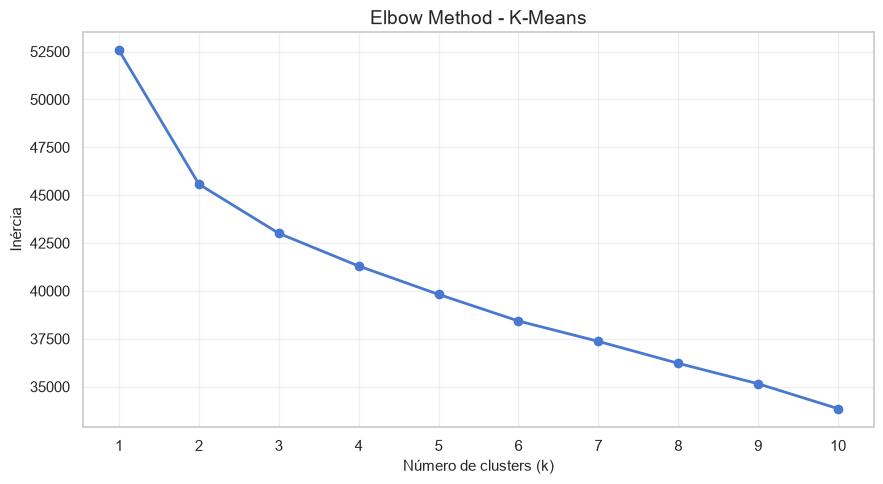

In [29]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(elbow_df["k"], elbow_df["inertia"], marker="o", linewidth=2)
ax.set_title("Elbow Method - K-Means")
ax.set_xlabel("Número de clusters (k)")
ax.set_ylabel("Inércia")
ax.set_xticks(k_values)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "elbow_method.png", dpi=300, bbox_inches="tight")
plt.show()


## 9. Escolha do número de clusters

A célula abaixo calcula uma sugestão automática para o ponto de cotovelo, medindo a maior distância entre os pontos da curva e a reta que liga `k=1` a `k=10`.

Depois de observar o gráfico, podemos manter o valor sugerido ou ajustar `k_final` manualmente caso o cotovelo visual indique uma escolha mais adequada.


In [30]:
points = elbow_df[["k", "inertia"]].to_numpy(dtype=float)
start = points[0]
end = points[-1]
line = end - start
line_norm = line / np.linalg.norm(line)

distances = []
for point in points:
    projection_length = np.dot(point - start, line_norm)
    projection = start + projection_length * line_norm
    distances.append(np.linalg.norm(point - projection))

suggested_k = int(elbow_df.loc[int(np.argmax(distances)), "k"])
k_final = suggested_k

print(f"k sugerido pela heuristica do cotovelo: {suggested_k}")
print(f"k_final utilizado: {k_final}")

k sugerido pela heuristica do cotovelo: 3
k_final utilizado: 3


## 10. K-Means

Com o número de clusters definido, aplicamos o K-Means sobre os dados padronizados. Cada imóvel passa a receber um rótulo de cluster, que será usado nas visualizações e na análise do perfil dos grupos.


In [31]:
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df_cluster["Cluster_KMeans"] = kmeans.fit_predict(X_scaled)

print("Quantidade de imoveis por cluster:")
print(df_cluster["Cluster_KMeans"].value_counts().sort_index())

Quantidade de imoveis por cluster:
Cluster_KMeans
0    400
1    354
2    706
Name: count, dtype: int64


## 11. Visualização dos clusters com PCA

O gráfico abaixo mostra os clusters no plano formado pelas duas primeiras componentes principais. Como o PCA resume várias variáveis em apenas dois eixos, a visualização serve como uma leitura geral da separação, e não como uma representação completa da base.


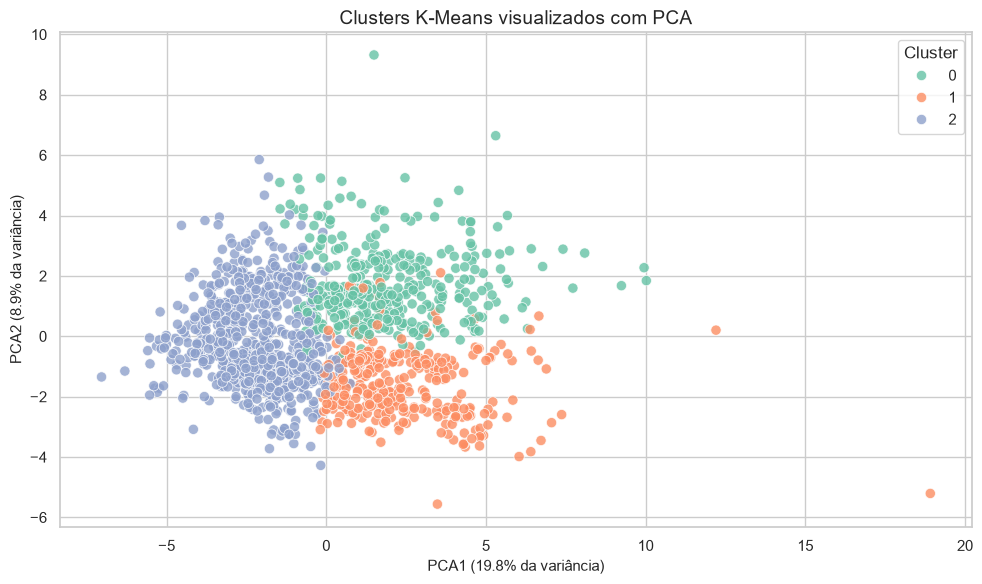

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=df_cluster,
    x="PCA1",
    y="PCA2",
    hue="Cluster_KMeans",
    palette="Set2",
    alpha=0.8,
    s=55,
    ax=ax
)
ax.set_title("Clusters K-Means visualizados com PCA")
ax.set_xlabel(f"PCA1 ({variancia_pca[0]:.1%} da variância)")
ax.set_ylabel(f"PCA2 ({variancia_pca[1]:.1%} da variância)")
ax.legend(title="Cluster")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "clusters_pca.png", dpi=300, bbox_inches="tight")
plt.show()


## 12. Visualização dos clusters com t-SNE

Usamos o t-SNE como visualização complementar. Ele costuma destacar estruturas locais dos dados, mas não substitui o PCA nem o Elbow Method como base principal da decisão sobre a clusterização.


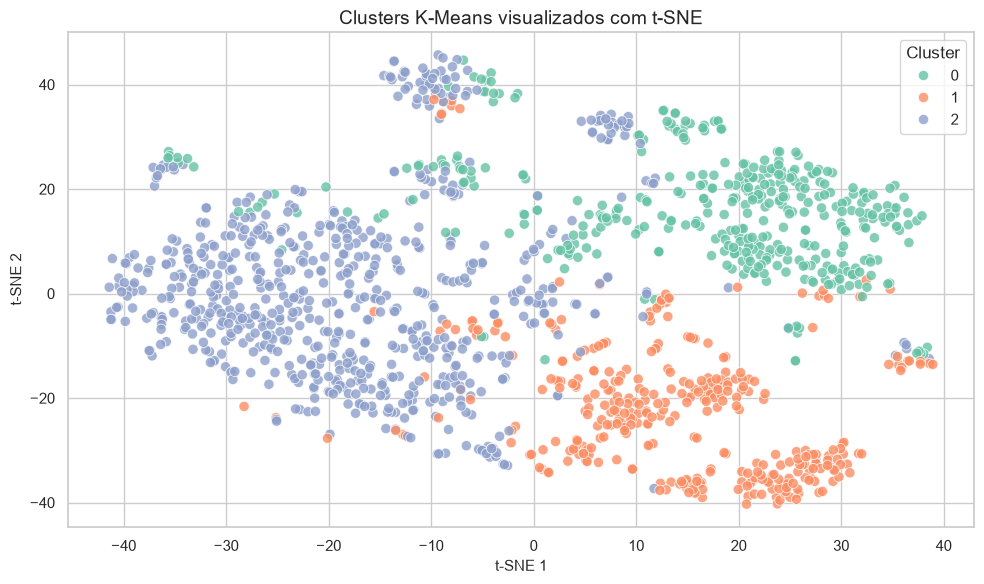

In [33]:
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    init="pca",
    learning_rate="auto"
)

X_tsne = tsne.fit_transform(X_scaled)
df_cluster["TSNE1"] = X_tsne[:, 0]
df_cluster["TSNE2"] = X_tsne[:, 1]

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=df_cluster,
    x="TSNE1",
    y="TSNE2",
    hue="Cluster_KMeans",
    palette="Set2",
    alpha=0.8,
    s=55,
    ax=ax
)
ax.set_title("Clusters K-Means visualizados com t-SNE")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(title="Cluster")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "clusters_tsne.png", dpi=300, bbox_inches="tight")
plt.show()


## 13. Perfil dos clusters

Depois de formar os clusters, usamos algumas variáveis de interpretação para entender melhor o perfil de cada grupo. Nesta etapa, `SalePrice` pode ser analisado, pois os grupos já foram criados e o preço não participou do treinamento.


In [34]:
profile_cols = [
    "SalePrice",
    "GrLivArea",
    "OverallQual",
    "TotalBsmtSF",
    "GarageCars",
    "YearBuilt",
    "FullBath",
    "TotRmsAbvGrd",
    "SalePrice_bin"
]

available_profile_cols = [col for col in profile_cols if col in df_cluster.columns]

agg_dict = {}
for col in available_profile_cols:
    if col == "SalePrice":
        agg_dict[col] = ["count", "mean", "median", "min", "max"]
    else:
        agg_dict[col] = ["mean"]

perfil_clusters = df_cluster.groupby("Cluster_KMeans").agg(agg_dict).round(2)
perfil_clusters.columns = ["_".join([str(part) for part in col]).strip("_") for col in perfil_clusters.columns.to_flat_index()]
perfil_clusters.to_csv(OUTPUT_DIR / "perfil_clusters.csv", encoding="utf-8")

perfil_clusters


,SalePrice_count,SalePrice_mean,SalePrice_median,SalePrice_min,SalePrice_max,GrLivArea_mean,OverallQual_mean,TotalBsmtSF_mean,GarageCars_mean,YearBuilt_mean,FullBath_mean,TotRmsAbvGrd_mean,SalePrice_bin_mean
Cluster_KMeans,,,,,,,,,,,,,
0,400,223024.90,200000.0,90000,755000,2001.36,6.84,956.54,2.13,1984.64,2.02,7.89,0.85
1,354,237176.28,215000.0,82500,611657,1643.93,7.16,1563.36,2.29,1994.26,1.90,6.64,0.91
2,706,128859.18,130000.0,34900,260000,1175.75,5.15,860.91,1.30,1952.17,1.14,5.68,0.10


## 14. Interpretação auxiliar dos clusters

A célula abaixo gera um resumo textual comparando cada cluster com a média geral da base. Esse resumo ajuda a transformar os grupos numéricos em uma leitura mais próxima do contexto do problema.


In [35]:
cluster_means = df_cluster.groupby("Cluster_KMeans")[available_profile_cols].mean(numeric_only=True)
overall_means = df_cluster[available_profile_cols].mean(numeric_only=True)

def compara(valor, referencia, tolerancia=0.05):
    if valor > referencia * (1 + tolerancia):
        return "acima da media"
    if valor < referencia * (1 - tolerancia):
        return "abaixo da media"
    return "proximo da media"

for cluster_id, row in cluster_means.iterrows():
    print(f"Cluster {cluster_id}")
    print(f"- Quantidade de imoveis: {(df_cluster['Cluster_KMeans'] == cluster_id).sum()}")
    if "SalePrice" in row.index:
        print(f"- Preco medio: {row['SalePrice']:.2f} ({compara(row['SalePrice'], overall_means['SalePrice'])})")
    if "GrLivArea" in row.index:
        print(f"- Area habitavel media: {row['GrLivArea']:.2f} ({compara(row['GrLivArea'], overall_means['GrLivArea'])})")
    if "OverallQual" in row.index:
        print(f"- Qualidade geral media: {row['OverallQual']:.2f} ({compara(row['OverallQual'], overall_means['OverallQual'])})")
    if "YearBuilt" in row.index:
        print(f"- Ano medio de construcao: {row['YearBuilt']:.0f} ({compara(row['YearBuilt'], overall_means['YearBuilt'], tolerancia=0.01)})")
    if "SalePrice_bin" in row.index:
        print(f"- Proporcao de imoveis caros: {row['SalePrice_bin']:.2%}")
    print()

Cluster 0
- Quantidade de imoveis: 400
- Preco medio: 223024.90 (acima da media)
- Area habitavel media: 2001.36 (acima da media)
- Qualidade geral media: 6.83 (acima da media)
- Ano medio de construcao: 1985 (proximo da media)
- Proporcao de imoveis caros: 85.00%

Cluster 1
- Quantidade de imoveis: 354
- Preco medio: 237176.28 (acima da media)
- Area habitavel media: 1643.93 (acima da media)
- Qualidade geral media: 7.16 (acima da media)
- Ano medio de construcao: 1994 (acima da media)
- Proporcao de imoveis caros: 90.68%

Cluster 2
- Quantidade de imoveis: 706
- Preco medio: 128859.18 (abaixo da media)
- Area habitavel media: 1175.75 (abaixo da media)
- Qualidade geral media: 5.15 (abaixo da media)
- Ano medio de construcao: 1952 (proximo da media)
- Proporcao de imoveis caros: 10.06%



## 15. Conclusão

Nesta etapa, aplicamos uma clusterização para separar os imóveis em grupos com características semelhantes. Primeiro, tratamos as colunas numéricas, removemos as variáveis que não deveriam participar do treinamento e padronizamos os dados. Depois, usamos PCA para visualização, Elbow Method para apoiar a escolha do número de clusters e K-Means para formar os grupos.

Pelas visualizações, os clusters apresentam separação razoável, principalmente quando observados pelo t-SNE. O PCA mostra a tendência geral dos grupos, enquanto o t-SNE ajuda a enxergar melhor a estrutura local dos dados.

A interpretação dos clusters deve ser feita a partir da tabela `perfil_clusters.csv` e do resumo textual gerado no notebook. Em geral, os grupos podem ser comparados por preço médio, área habitável, qualidade geral, área de porão, quantidade de vagas de garagem, ano de construção e proporção de imóveis acima da mediana de preço.

O ponto mais importante da etapa é que `SalePrice` não foi usado para treinar o K-Means. O preço foi utilizado somente depois da clusterização, como apoio para interpretar os perfis encontrados. Dessa forma, os clusters refletem as características dos imóveis, e não uma separação forçada pelo valor de venda.
